# GAN sur SHAPES : du MLP vanilla au WGAN-GP convolutif

Deux reseaux jouent l'un contre l'autre :

1. Generateur `G` : bruit `z` -> fausse image. Il veut tromper `D`.
2. Discriminateur `D` : image -> score (reelle ou fausse). Il veut ne pas etre trompe.

Le GAN n'a pas d'encodeur : il n'existe aucune fonction `x -> z`. Les trois taches sont traitees
ainsi, la ou deux d'entre elles demandent un detour :

| Tache | Moyen |
|---|---|
| Generation de donnees synthetiques | `generate()` |
| Compression / Decompression | `invert()` puis `decode()`, par descente de gradient sur `z` |
| Projection pour visualisation | `extract_features()`, discriminateur recycle en extracteur |

Ce notebook est le pendant shapes de `06_gan.ipynb` (MNIST). Il n'en reprend pas la conclusion : la
configuration qui converge sur MNIST **echoue ici**, et l'essentiel du travail a consiste a mesurer
pourquoi. On part donc de la config MNIST telle quelle, on constate son echec, et on ne change
d'architecture qu'en reponse a une pathologie mesuree.

shapes est plus dur que MNIST sur trois points : couleur (3072 dimensions contre 784), geometrie a
bords francs plutot que des traits, et fond bruite parseme de parasites.

In [1]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from src.dataset import load_shapes_dataset
from src.gan import GAN, WGANGP
from src.autoencoder import AutoEncoder
from src.pca import PCA
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

np.random.seed(0)
torch.manual_seed(0)
%matplotlib inline

print("device:", get_device())

IMAGE_SHAPE = (3, 32, 32)          # (C, H, W), soit 3072 features une fois aplati
DATA_DIM = int(np.prod(IMAGE_SHAPE))
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS_MLP = 60                    # meme budget que MNIST, pour comparer a config egale
EPOCHS_WGAN = 250
EPOCHS_AE = 150                    # l'AE de reference doit avoir converge, cf. tache 2
N_EVAL = 10000                     # N du pipeline partage : ratio comparable a K-Means / PCA
N_PROJECTION = 3000
INVERSION_STEPS = 300

device: mps


In [2]:
def flattened_vector_to_image(flat_vector, image_shape):
    # (D,) -> (H, W) en gris ou (H, W, C) en couleur, pret pour imshow
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def show_image_grid(samples, image_shape, n_rows=2, n_cols=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(flattened_vector_to_image(samples[i], image_shape), 0, 1), cmap=cmap)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_original_vs_reconstruction_grid(originals, reconstructions, image_shape, n=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3))
    for i in range(n):
        axes[0, i].imshow(np.clip(flattened_vector_to_image(originals[i], image_shape), 0, 1), cmap=cmap)
        axes[1, i].imshow(np.clip(flattened_vector_to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        axes[0, i].axis("off"); axes[1, i].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

## Partie A - Dataset SHAPES

Pipeline partage du projet, a l'identique : `load_shapes_dataset` sur le sous-dossier `train`,
`extract_full_dataset`, puis les 10000 premieres images aplaties a la volee.

Deux points de vigilance. Le loader vise `data/shapes_hard_color/train` et non la racine : pointe
sur la racine il detecte `['train', 'validation']` comme classes. Et le `shuffle=True` avec
`torch.manual_seed(0)` fixe le sous-ensemble : les effectifs par forme ci-dessous doivent etre
identiques a ceux de `01_kmeans_shapes.ipynb`, sinon les MSE et les ratios ne sont pas comparables
entre algorithmes.

X: (10000, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
formes : ['bar', 'circle', 'cross', 'square', 'star', 'triangle']
effectifs par forme : [1610, 1691, 1686, 1656, 1726, 1631]


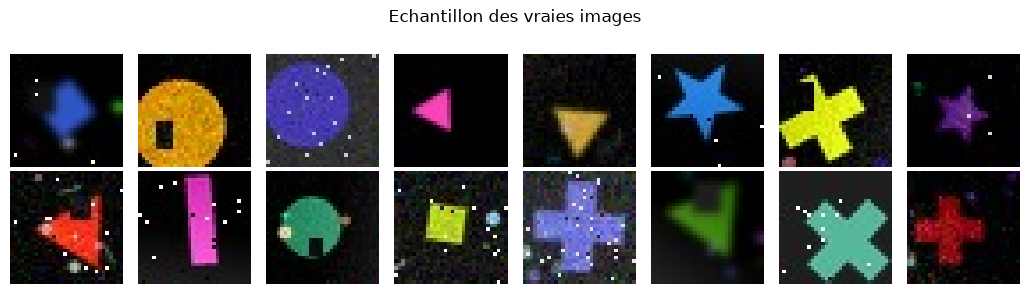

In [3]:
torch.manual_seed(0)
dataloader = load_shapes_dataset(data_dir="data/shapes_hard_color/train", batch_size=4096, shuffle=True)
images, shape_labels = extract_full_dataset(dataloader)

class_names = list(dataloader.dataset.classes)

# images : (N, C, H, W) -> aplati a la volee, comme impose par le contrat d'interface
X = images[:N_EVAL].flatten(start_dim=1).numpy().astype(np.float32)
y = shape_labels[:N_EVAL].numpy()

print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("formes :", class_names)
print("effectifs par forme :", np.bincount(y).tolist())
show_image_grid(X, IMAGE_SHAPE, title="Echantillon des vraies images")

### Etape 1 - la configuration MNIST, telle quelle

Meme classe `GAN`, meme latent, meme budget, seul `data_dim` passe de 784 a 3072. L'implementation
est agnostique a la dimension : rien n'empeche de la lancer ici, la question est de savoir si elle
converge.

Rappel du protocole (identique a MNIST, detaille dans `06_gan.ipynb`) : un pas sur `D` avec les
fausses `.detach()`, puis un pas sur `G` avec `D` gele, loss BCE non saturante pour `G`, batchs
melanges, `drop_last=True`, images ramenees en `[-1, 1]` en interne pour le Tanh de `G`.

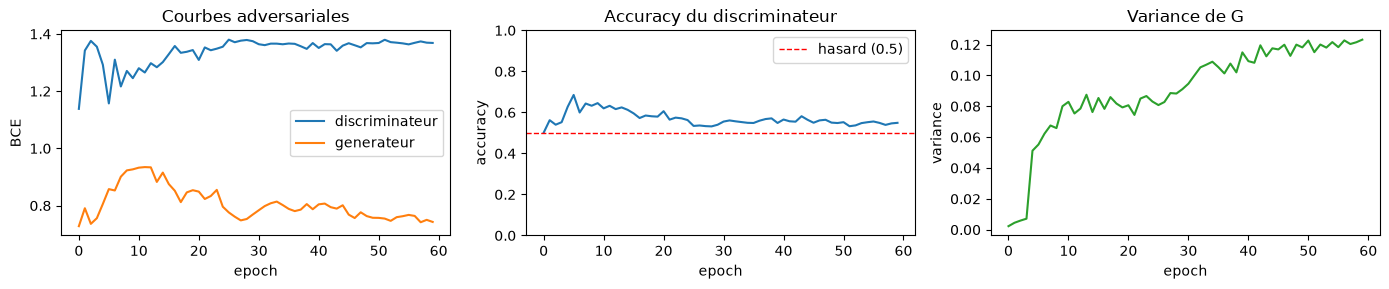

accuracy finale de D: 0.549
variance finale de G: 0.1232
loss finale D: 1.368 | loss finale G: 0.743


In [4]:
np.random.seed(0); torch.manual_seed(0)

mlp_gan = GAN(data_dim=DATA_DIM, latent_dim=LATENT_DIM)
mlp_gan.fit(X, epochs=EPOCHS_MLP, batch_size=BATCH_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(mlp_gan.loss_history["discriminator"], label="discriminateur")
axes[0].plot(mlp_gan.loss_history["generator"], label="generateur")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE"); axes[0].set_title("Courbes adversariales")
axes[0].legend()

axes[1].plot(mlp_gan.metric_history["discriminator_accuracy"])
axes[1].axhline(0.5, color="red", ls="--", lw=1, label="hasard (0.5)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy du discriminateur"); axes[1].legend()

axes[2].plot(mlp_gan.metric_history["generator_variance"], color="tab:green")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("variance"); axes[2].set_title("Variance de G")
plt.tight_layout(); plt.show()

print("accuracy finale de D:", round(mlp_gan.metric_history["discriminator_accuracy"][-1], 3))
print("variance finale de G:", round(mlp_gan.metric_history["generator_variance"][-1], 4))
print("loss finale D:", round(mlp_gan.loss_history["discriminator"][-1], 3),
      "| loss finale G:", round(mlp_gan.loss_history["generator"][-1], 3))

Toutes les metriques d'equilibre sont **bonnes**, et meilleures que sur MNIST : l'accuracy de `D`
se cale a 0.549, juste au-dessus du 0.5 vise (contre 0.63 sur MNIST), les deux loss plafonnent a
1.368 et 0.743 sans que l'une ecrase l'autre, la variance de `G` monte et se stabilise a 0.123.

Aucun des trois scenarios d'echec listes dans `06_gan.ipynb` ne se declenche : ni loss de `D` qui
s'effondre, ni loss de `G` qui explose, ni variance qui s'ecroule. Reste a regarder les images.

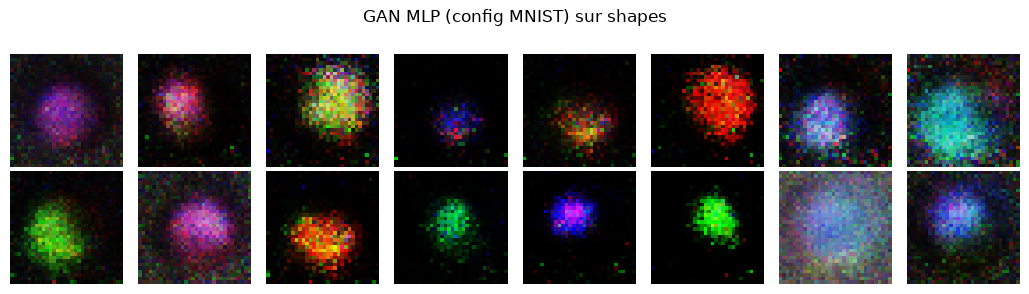

ecart-type inter-images (genere): 0.1595
ecart-type inter-images (reel)  : 0.1765


In [5]:
mlp_fake = mlp_gan.generate(16, seed=0)
show_image_grid(mlp_fake, IMAGE_SHAPE, title="GAN MLP (config MNIST) sur shapes")

print("ecart-type inter-images (genere):", round(float(mlp_gan.generate(64, seed=1).std(axis=0).mean()), 4))
print("ecart-type inter-images (reel)  :", round(float(X.std(axis=0).mean()), 4))

### Diagnostic : les metriques d'equilibre ne mesurent pas la qualite

Des taches de couleur. Aucun bord franc, aucune forme identifiable, alors que les metriques
annoncaient une partie saine et que la diversite est correcte (ecart-type inter-images 0.1595
contre 0.1765 au reel, donc pas de mode collapse).

C'est le point a retenir de cette etape : les metriques d'equilibre disent que `D` et `G` sont a
egalite, pas que `G` produit quelque chose de bon. Ici l'egalite est obtenue **par le bas**.

Le vrai signal etait sous nos yeux : l'accuracy de `D` plafonne a 0.549 sur des faux qu'un humain
rejette au premier coup d'oeil. Ce n'est pas que `G` est bon, c'est que **`D` est aveugle**. Un MLP
recoit 3072 pixels sans aucune notion de voisinage : il n'a pas de quoi representer un bord. Il juge
donc sur des statistiques de couleur, et `G` n'a qu'a les reproduire pour gagner. Sur MNIST cela
suffisait a produire des chiffres, les traits blancs sur fond noir etant largement portes par ces
statistiques ; ici la geometrie ne l'est pas.

Le reflexe herite du developpement MNIST etait de corriger un desequilibre (`journal_dev_gan.md`,
16/07 15:30). Il ne s'applique pas. Controles mesures (detail dans le journal, entree du 17/07
09:30) : retirer le dropout de `D` (accuracy 0.575), le baisser a 0.1 (0.562), ou multiplier
l'entrainement par 2.5 (150 epochs, 0.555) ne fait apparaitre **aucune forme**. Le probleme n'est ni
l'equilibre, ni la duree : il est representationnel.

Il faut donner a `D` et a `G` un prior spatial, donc des convolutions.

### Etape 2 - convolutions, puis WGAN-GP

Deux changements, chacun en reponse a une mesure. Le detail est dans `journal_dev_gan.md` (entrees
du 17/07 10:15 et 11:00) ; le resume :

**1. Convolutions (DCGAN).** Avec un `G` et un `D` convolutifs et la meme loss BCE, les bords francs
et les aplats de couleur reviennent immediatement : le prior spatial etait bien ce qui manquait.
Mais l'equilibre casse dans l'autre sens, l'accuracy de `D` monte a **0.998** et la loss de `G`
diverge, exactement la pathologie du 16/07 15:30. Et le correctif MNIST se retourne : le
`Dropout2d` ramene bien l'accuracy vers 0.8, mais il detruit les detecteurs de bords qui venaient
de nous donner la structure. Avec une loss BCE, soit `D` voit et ecrase `G`, soit on l'aveugle et
il n'y a plus de geometrie.

**2. WGAN-GP.** La cause est la **saturation** du BCE : `D` sort une probabilite, et quand il separe
parfaitement ses logits saturent, le gradient vers `G` meurt. Le critique de Wasserstein sort un
score **non borne**, l'ecart entre vrai et faux reste exploitable quel que soit son niveau. La
contrainte de 1-Lipschitz est imposee par une **penalite de gradient** et non par le clipping des
poids du cours : le clipping ampute la capacite du critique, ce qui nous ramenerait au probleme du
dropout. Le critique utilise LayerNorm et non BatchNorm, la penalite etant definie echantillon par
echantillon.

On ne migre donc pas pour la nouveaute : WGAN-GP repond a une pathologie precise, mesuree ici. Les
autres pistes du cours (Progressive Growing, MSG-GAN) repondent a des problemes de montee en
resolution que du 32x32 ne pose pas.

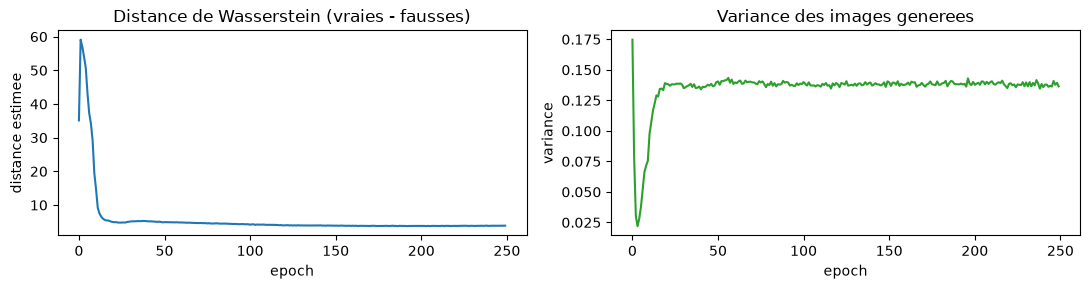

distance de Wasserstein : depart 35.13 -> fin 3.87
variance finale de G: 0.1365


In [6]:
np.random.seed(0); torch.manual_seed(0)

# WGANGP(image_shape=(C, H, W), latent_dim) : meme API publique que GAN, seuls __init__ et fit changent
gan = WGANGP(image_shape=IMAGE_SHAPE, latent_dim=LATENT_DIM)
gan.fit(X, epochs=EPOCHS_WGAN, batch_size=BATCH_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(gan.metric_history["wasserstein"])
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("distance estimee")
axes[0].set_title("Distance de Wasserstein (vraies - fausses)")

axes[1].plot(gan.metric_history["generator_variance"], color="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("variance")
axes[1].set_title("Variance des images generees")
plt.tight_layout(); plt.show()

print("distance de Wasserstein : depart", round(gan.metric_history["wasserstein"][0], 2),
      "-> fin", round(gan.metric_history["wasserstein"][-1], 2))
print("variance finale de G:", round(gan.metric_history["generator_variance"][-1], 4))

### Lecture de la courbe

Difference de nature avec le GAN vanilla : **cette courbe veut dire quelque chose**. Avec le BCE,
une loss qui descend etait une alerte, les deux reseaux ayant des objectifs opposes. Ici la distance
de Wasserstein estime l'ecart entre les deux distributions : elle decroit quand les images
s'ameliorent, et plateau quand `G` a fini de progresser. On peut enfin decider de la duree
d'entrainement sur un chiffre plutot qu'a l'oeil.

Elle chute de 35.13 a environ 5 en une vingtaine d'epochs, puis descend lentement jusqu'a **3.87**
et plateau. La variance de `G` reste stable a 0.1365 : pas de mode collapse.

Le plateau porte deux informations. La premiere est utile : ce n'est plus la duree d'entrainement
qui limite, ajouter des epochs ne rendra rien. La seconde est plus genante : la distance plateau a
3.87 et **non a zero**. Le critique separe donc toujours les vraies des fausses. On y revient a la
tache 1.

## Tache 1 - Generation de donnees synthetiques

shape: (16, 3072) | valeurs dans (0.0, 1.0)


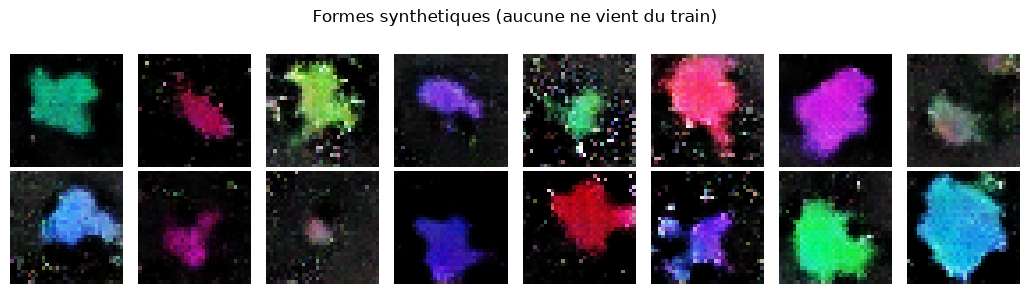

In [7]:
# generate(n, seed) -> (n, 3072), float32 dans [0, 1]
fake = gan.generate(16, seed=0)
print("shape:", fake.shape, "| valeurs dans", (round(float(fake.min()), 3), round(float(fake.max()), 3)))
show_image_grid(fake, IMAGE_SHAPE, title="Formes synthetiques (aucune ne vient du train)")

### Verification du mode collapse

Risque : `G` trouve une image qui trompe le critique et ne produit plus qu'elle. On genere un lot
large et on compare l'ecart-type pixel a pixel entre images a celui des vraies donnees.

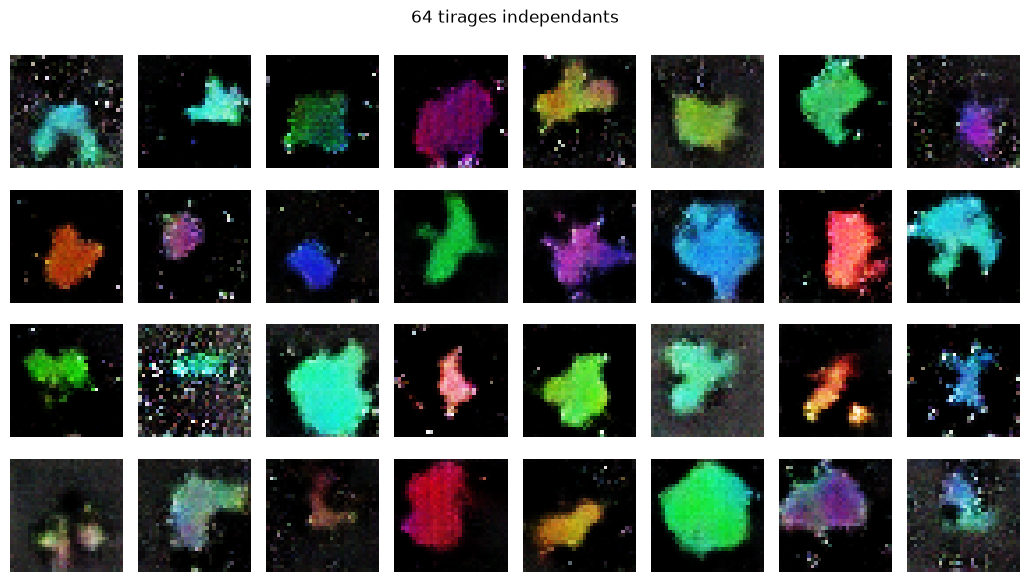

ecart-type inter-images (genere): 0.1734
ecart-type inter-images (reel)  : 0.1765


In [8]:
sample_batch = gan.generate(64, seed=1)
show_image_grid(sample_batch, IMAGE_SHAPE, n_rows=4, n_cols=8, title="64 tirages independants")

print("ecart-type inter-images (genere):", round(float(sample_batch.std(axis=0).mean()), 4))
print("ecart-type inter-images (reel)  :", round(float(X.std(axis=0).mean()), 4))

Ecart-type inter-images 0.1734 contre 0.1765 au reel, soit 98% de la diversite des vraies donnees,
et la variance de `G` etait stable pendant tout l'entrainement. **Pas de mode collapse** : les 64
tirages sont bien distincts les uns des autres.

Ce qui isole proprement le probleme : les images ne sont pas peu variees, elles sont variees et
fausses. La diversite ne dit rien de la qualite, pas plus que les metriques d'equilibre.

### Combien reste-t-il a parcourir ?

La distance de Wasserstein plateau a une valeur non nulle : le critique separe donc encore. On lui
demande de noter les vraies et les fausses pour situer l'ecart residuel. Le score n'est pas une
probabilite, seul l'ecart entre les moyennes a un sens.

In [9]:
def critic_score(batch):
    # (N, 3072) dans [0, 1] -> (N,) scores du critique. eval() : LayerNorm inchangee, mais on coupe
    # tout comportement dependant du mode, et on ne veut pas de gradient.
    gan.discriminator.eval()
    with torch.no_grad():
        tensor = torch.from_numpy(batch).float().to(gan.device) * 2.0 - 1.0
        scores = gan.discriminator(tensor).cpu().numpy().ravel()
    gan.discriminator.train()
    return scores

for name, batch in [("vraies images", X[:512]), ("G(z), z ~ N(0, I)", gan.generate(512, seed=3))]:
    scores = critic_score(batch)
    print(f"score du critique, {name:20s}: moyenne {scores.mean():7.2f} | ecart-type {scores.std():.2f}")

score du critique, vraies images       : moyenne   -7.18 | ecart-type 2.44
score du critique, G(z), z ~ N(0, I)   : moyenne  -10.97 | ecart-type 1.20


L'ecart est net : **-7.18 pour les vraies contre -10.97 pour les fausses**, soit 3.79 d'ecart, a
comparer aux ecarts-types (2.44 et 1.20). Le critique n'est pas dupe, et c'est exactement ce que
disait la distance de Wasserstein en plateau a 3.87.

**Verdict de la tache 1 : echec sur ce dataset.** Ce que `G` a appris est reel mais partiel : la
palette de couleurs, le fond sombre, les parasites, un objet unique et compact au centre. Ce qu'il
n'a pas appris, c'est la **geometrie** : aucune des six formes n'est identifiable. Le contraste avec
MNIST est net, ou les chiffres etaient reconnaissables et varies.

Le resultat est negatif et il reste. Il faut noter ce qui a ete gagne malgre tout : le WGAN-GP a
supprime les pathologies d'entrainement (saturation, dominance de `D`, collapse) et fourni une
courbe qui se lit. Ce qui reste n'est pas un probleme d'optimisation mais de capacite a couvrir la
distribution en 250 epochs sur 10000 images. Les pistes restantes se mesurent en budget : plus de
donnees (le dataset complet en compte davantage), un `G` plus large, ou une architecture
conditionnee par la classe.

## Tache 2 - Compression / Decompression

Le generateur est un decodeur `z -> x`, mais rien ne code une image existante. Pour obtenir son code
latent il faut le **chercher** : `G` est fige et une descente de gradient est menee sur `z` lui-meme
pour minimiser `||G(z) - x||`. C'est `GAN.invert()`.

Ce n'est pas un encodeur : l'AutoEncoder code en une passe avant, ici il faut 300 pas de gradient.

`N_EVAL = 10000`, soit le N du pipeline partage. Ce choix est delibere : le codebook est un cout
fixe amorti sur N, donc le ratio de compression n'a de sens entre algorithmes que si le N est le
meme. C'est le N sur lequel `01_kmeans_shapes.ipynb` et `02_pca_shapes.ipynb` publient leurs
chiffres. Corollaire : le ratio ci-dessous n'est **pas** comparable a celui de `06_gan.ipynb`, qui
mesure sur 1000 images.

code latent par image: 100 valeurs | nature: continuous


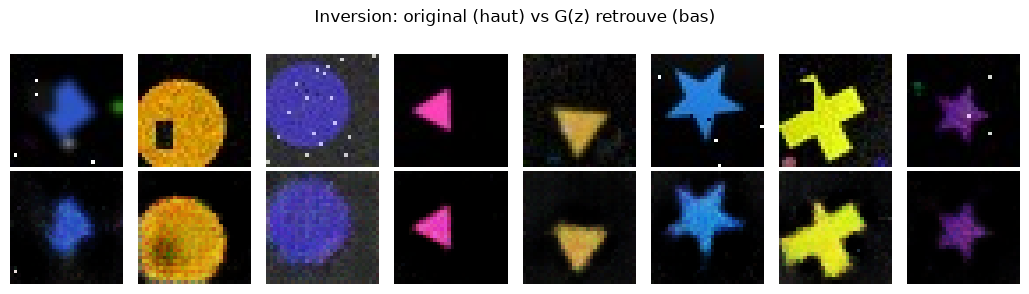

In [10]:
# invert(X, steps, seed) -> Latent de shape (N, latent_dim), nature "continuous"
gan_latent = gan.invert(X[:N_EVAL], steps=INVERSION_STEPS, seed=0)
gan_reconstructed = gan.decode(gan_latent)
print("code latent par image:", gan_latent.array.shape[1], "valeurs | nature:", gan_latent.nature)

show_original_vs_reconstruction_grid(X, gan_reconstructed, IMAGE_SHAPE, n=8,
                     title="Inversion: original (haut) vs G(z) retrouve (bas)")

Resultat inattendu au regard de la tache 1 : l'inversion retrouve **les formes**, avec la bonne
couleur, la bonne taille et la bonne position. Losange bleu, cercle orange texture, cercle violet,
triangle rose, triangle orange, etoile bleue, croix jaune, etoile violette. Seuls les parasites
blancs du fond disparaissent.

C'est le **meme generateur** que celui qui produit des taches quand on tire `z` dans le prior. Le
fait est mesure, il est note, on l'explique apres les chiffres de compression.

In [11]:
gan_report = compression_report(gan.get_codebook(), gan_latent, X[:N_EVAL], gan_reconstructed)

# Deux references a dimension latente identique (100), pour que la comparaison porte sur le modele.
# L'AE est entraine jusqu'a convergence : a 15 epochs (le budget du notebook MNIST) il plafonne a
# 0.0116 de MSE et le GAN paraitrait meilleur, ce qui ne dirait rien d'autre qu'un budget inegal.
np.random.seed(0); torch.manual_seed(0)
autoencoder = AutoEncoder(
    input_dim=DATA_DIM, output_dim=DATA_DIM, latent_dim=LATENT_DIM,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU, fonction_loss=nn.MSELoss
)
autoencoder.fit(X, epochs=EPOCHS_AE, batch_size=BATCH_SIZE)
ae_latent = autoencoder.encode(X[:N_EVAL])
ae_reconstructed = autoencoder.decode(ae_latent)
ae_report = compression_report(autoencoder.get_codebook(), ae_latent, X[:N_EVAL], ae_reconstructed)

pca = PCA(n_components=LATENT_DIM).fit(X)
pca_latent = pca.encode(X[:N_EVAL])
pca_reconstructed = pca.decode(pca_latent)
pca_report = compression_report(pca.get_codebook(), pca_latent, X[:N_EVAL], pca_reconstructed)

print(f"{'critere':<26}{'GAN (WGAN-GP)':>15}{'AutoEncoder':>14}{'PCA':>14}")
for key in ["reconstruction_mse", "codebook_bytes", "latent_bytes", "compression_ratio"]:
    fmt = lambda v: f"{v:.5f}" if isinstance(v, float) else str(v)
    print(f"{key:<26}{fmt(gan_report[key]):>15}{fmt(ae_report[key]):>14}{fmt(pca_report[key]):>14}")

critere                     GAN (WGAN-GP)   AutoEncoder           PCA
reconstruction_mse                0.00706       0.00477       0.00766
codebook_bytes                    4296472      13411860       1241088
latent_bytes                      4000000       4000000       4000000
compression_ratio                14.81111       7.05726      23.44551


### Lecture

Trois enseignements, dont un qui contredit MNIST.

**1. Le ratio est superieur a 1, et largement (14.81).** Sur MNIST il valait 0.49 : le GAN gonflait
les donnees. Deux raisons, aucune n'est un progres du modele. Le plafond theorique est ici de
`3072 / 100 = 30.72` contre 7.84 sur MNIST, les images etant 4x plus grandes a dimension latente
egale. Et le `G` convolutif ne pese que **4.3 Mo contre 5.9 Mo** pour le `G` MLP de MNIST, alors
qu'il produit des images 4x plus grandes : les convolutions partagent leurs poids, un MLP non.

**2. L'AutoEncoder reste meilleur en reconstruction** (0.00477 contre 0.00706). La conclusion de
MNIST tient. Mais son decodeur pese 13.4 Mo, soit 3x le generateur, et son ratio est donc deux fois
moindre (7.06 contre 14.81). Le GAN est battu sur la qualite, il gagne sur le poids du codebook.

**3. La PCA domine les deux** sur le ratio (23.45) avec une MSE (0.00766) comparable a celle du GAN,
pour un codebook de 1.2 Mo et sans aucun entrainement adverse.

Point de methode, qui a failli produire une conclusion fausse : l'AE est ici entraine **150 epochs**.
Avec les 15 epochs du notebook MNIST il plafonne a 0.0116 de MSE et le GAN semblerait le battre.
Cela n'aurait mesure qu'un budget inegal, 250 epochs contre 15 (`journal_dev_gan.md`, 17/07 12:20).

Le cout, lui, ne se lit pas dans le tableau : les 100 valeurs latentes du GAN demandent **300 pas de
gradient par image** a l'encodage, la ou l'AE fait une passe avant et la PCA un produit matriciel.

### Distribution de l'erreur, image par image

La MSE moyenne cache la forme de la distribution. Sur MNIST, l'inversion echouait completement sur
certains chiffres, sans antecedent dans l'espace latent. La queue de distribution le dit.

GAN          MSE par image : mediane 0.00568 | p90 0.01453 | max 0.05678
AutoEncoder  MSE par image : mediane 0.00433 | p90 0.00842 | max 0.01923


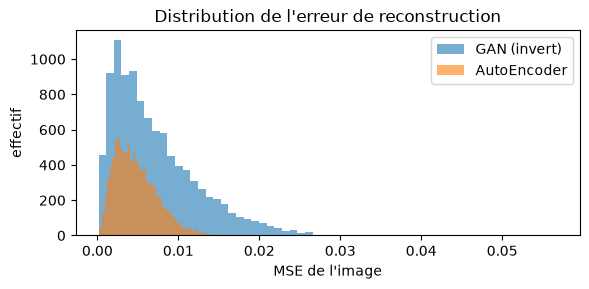

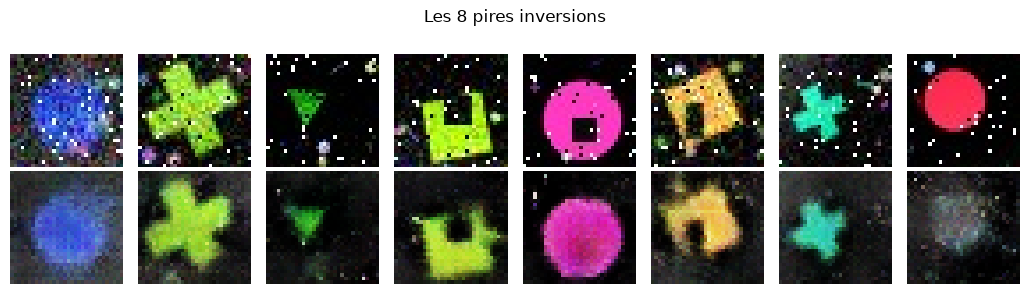

In [12]:
gan_per_image = ((X[:N_EVAL] - gan_reconstructed) ** 2).mean(axis=1)
ae_per_image = ((X[:N_EVAL] - ae_reconstructed) ** 2).mean(axis=1)

for name, errors in [("GAN", gan_per_image), ("AutoEncoder", ae_per_image)]:
    print(f"{name:12s} MSE par image : mediane {np.median(errors):.5f} | p90 {np.percentile(errors, 90):.5f} "
          f"| max {errors.max():.5f}")

plt.figure(figsize=(6, 3))
plt.hist(gan_per_image, bins=60, alpha=0.6, label="GAN (invert)")
plt.hist(ae_per_image, bins=60, alpha=0.6, label="AutoEncoder")
plt.xlabel("MSE de l'image"); plt.ylabel("effectif"); plt.legend()
plt.title("Distribution de l'erreur de reconstruction"); plt.tight_layout(); plt.show()

worst = np.argsort(gan_per_image)[-8:]
show_original_vs_reconstruction_grid(X[worst], gan_reconstructed[worst], IMAGE_SHAPE, n=8,
                     title="Les 8 pires inversions")

La queue du GAN est plus lourde que celle de l'AE : p90 a 0.0145 contre 0.0084, et surtout un max a
**0.0568 contre 0.0192**, soit trois fois pire.

Mais les 8 pires inversions restent des **formes reconnaissables** : cercle bleu, croix verte,
triangle vert, croix jaune, cercle magenta, carre orange, etoile cyan. Elles sont plus floues, et
ce sont les images les plus parsemees de parasites blancs, que `G` lisse au lieu de les reproduire.

**Le mode dropping observe sur MNIST ne se reproduit pas ici.** Sur MNIST, certains chiffres reels
degeneraient en tache a l'inversion, sans aucun antecedent dans l'espace latent. Sur shapes, meme
les pires cas gardent leur geometrie : l'erreur est dominee par un bruit de fond que `G` ne modelise
pas, pas par des images qu'il serait incapable de produire. Un resultat negatif attendu qui ne se
confirme pas est un resultat aussi.

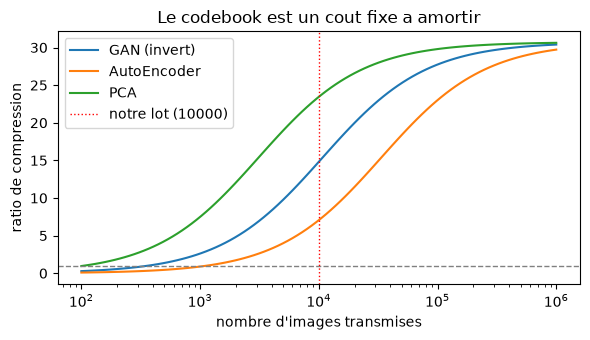

le GAN devient rentable au-dela de 361 images
plafond theorique (codebook amorti): 30.72


In [13]:
def compression_ratio_curve(codebook_bytes, latent_dim, data_dim, n_images):
    # -> (len(n_images),) : ratio original / (codebook + latent) en fonction du nombre d'images
    original = n_images * data_dim * 4
    compressed = codebook_bytes + n_images * latent_dim * 4
    return original / compressed

n_images = np.logspace(2, 6, 100)
plt.figure(figsize=(6, 3.5))
for label, report in [("GAN (invert)", gan_report), ("AutoEncoder", ae_report), ("PCA", pca_report)]:
    plt.plot(n_images, compression_ratio_curve(report["codebook_bytes"], LATENT_DIM, DATA_DIM, n_images), label=label)
plt.axhline(1, color="grey", ls="--", lw=1)
plt.axvline(N_EVAL, color="red", ls=":", lw=1, label=f"notre lot ({N_EVAL})")
plt.xscale("log"); plt.xlabel("nombre d'images transmises"); plt.ylabel("ratio de compression")
plt.title("Le codebook est un cout fixe a amortir"); plt.legend(); plt.tight_layout(); plt.show()

# Seuil de rentabilite : ratio = 1, soit codebook = N * (gain par image)
print("le GAN devient rentable au-dela de",
      int(gan_report["codebook_bytes"] / ((DATA_DIM - LATENT_DIM) * 4)), "images")
print("plafond theorique (codebook amorti):", round(DATA_DIM / LATENT_DIM, 2))

Le seuil de rentabilite tombe a **361 images**, contre environ 2170 sur MNIST : le codebook est plus
leger et le gain par image bien plus grand (3072 valeurs remplacees par 100). Sur notre lot de 10000
on est a 14.81, soit environ la moitie du plafond de 30.72 vers lequel la courbe tend.

La courbe montre aussi que le GAN passe devant l'AutoEncoder tres tot, des quelques centaines
d'images, et que l'ecart se creuse : c'est le poids du codebook qui les separe, pas la qualite. La
PCA reste au-dessus des deux sur toute la plage.

### Un generateur, deux qualites d'image

L'inversion retrouve des formes correctes, alors que le tirage direct dans le prior donne des
taches : c'est le meme `G`. Le premier soupcon est que l'inversion sorte de la zone ou le prior a
sa masse, en allant chercher des `z` de norme atypique. On mesure.

Interpolation lineaire entre deux `z`, chaque etape decodee. Deux chemins : entre deux `z` tires du
prior, et entre deux `z` issus de l'inversion.

In [14]:
print("||z|| des codes trouves par invert : mediane",
      round(float(np.median(np.linalg.norm(gan_latent.array, axis=1))), 2),
      "| min", round(float(np.linalg.norm(gan_latent.array, axis=1).min()), 2),
      "| max", round(float(np.linalg.norm(gan_latent.array, axis=1).max()), 2))
prior_sample = np.random.randn(N_EVAL, LATENT_DIM)
print("||z|| des codes tires du prior    : mediane",
      round(float(np.median(np.linalg.norm(prior_sample, axis=1))), 2),
      "| min", round(float(np.linalg.norm(prior_sample, axis=1).min()), 2),
      "| max", round(float(np.linalg.norm(prior_sample, axis=1).max()), 2))
print("ecart-type par coordonnee : invert", round(float(gan_latent.array.std()), 3),
      "| prior", round(float(prior_sample.std()), 3))

print("score du critique, G(z) avec z issu de invert :",
      round(float(critic_score(gan_reconstructed[:512]).mean()), 2))

||z|| des codes trouves par invert : mediane 9.37 | min 6.82 | max 15.62
||z|| des codes tires du prior    : mediane 9.97 | min 7.18 | max 12.68
ecart-type par coordonnee : invert 0.947 | prior 1.0
score du critique, G(z) avec z issu de invert : -9.48


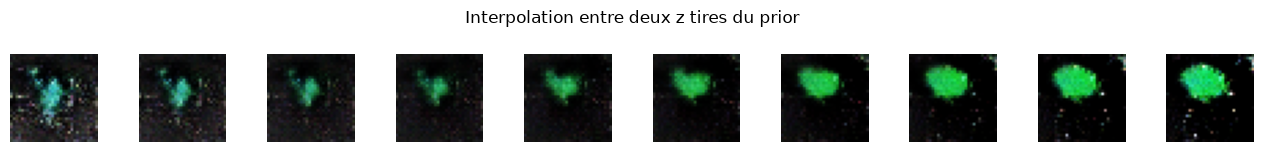

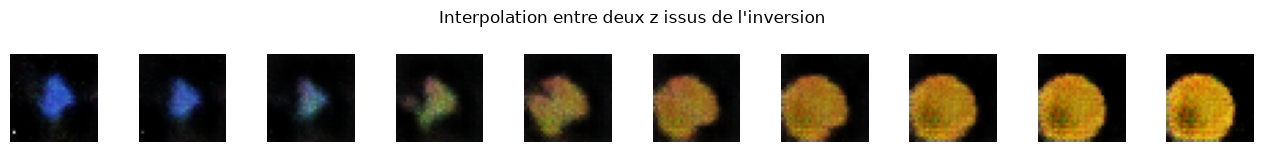

In [15]:
def interpolate(gan, z_a, z_b, n_steps=10):
    # z_a, z_b : (latent_dim,) -> (n_steps, data_dim), chemin decode par le generateur
    weights = np.linspace(0, 1, n_steps).reshape(-1, 1)
    path = ((1 - weights) * z_a + weights * z_b).astype(np.float32)
    return gan.decode(Latent(array=path, nature="continuous"))

torch.manual_seed(2)
z_prior_a, z_prior_b = gan.sample_noise(1).cpu().numpy()[0], gan.sample_noise(1).cpu().numpy()[0]
show_image_grid(interpolate(gan, z_prior_a, z_prior_b), IMAGE_SHAPE, n_rows=1, n_cols=10,
                title="Interpolation entre deux z tires du prior")
show_image_grid(interpolate(gan, gan_latent.array[0], gan_latent.array[1]), IMAGE_SHAPE, n_rows=1, n_cols=10,
                title="Interpolation entre deux z issus de l'inversion")

### Ce que la mesure dit, et ce qu'elle ne dit pas

**L'hypothese tombe.** Les codes trouves par inversion ont une norme mediane de 9.37 contre 9.97
pour le prior, et un ecart-type par coordonnee de 0.947 contre 1.0. Ils sont **dans** le prior. Un
petit nombre depasse la norme maximale d'un echantillon du prior (15.62 contre 12.68), mais la masse
est au meme endroit : l'inversion ne va pas chercher des `z` atypiques.

Les scores du critique confirment l'ecart de qualite sans l'expliquer : vraies **-7.18**,
`G(z inverse)` **-9.48**, `G(z ~ prior)` **-10.97**. Les reconstructions sont jugees plus credibles
que les tirages du prior, et les deux restent en deca des vraies.

Les deux interpolations montrent la meme chose visuellement. Entre deux `z` du prior, le chemin
reste dans les taches d'un bout a l'autre. Entre deux `z` issus de l'inversion, le morphing est
continu et **chaque etape est une forme plausible** : un losange bleu se deforme progressivement en
cercle orange. La variete des formes existe donc bien dans l'espace latent, elle est continue, et
elle est atteignable par descente de gradient.

Interpretation, en restant sur ce qui est mesure : en dimension 100, une region peut partager les
statistiques marginales du prior (norme, ecart-type par coordonnee) tout en etant de masse
negligeable. La variete des formes serait dans ce cas atteignable par optimisation mais quasiment
jamais echantillonnee. C'est cohérent avec une distance de Wasserstein qui plateau a 3.87 et non a
zero : la distribution poussee par `G` ne coincide pas avec celle des donnees. Le mecanisme precis
n'est pas mesure ici et ne sera pas invente.

Consequence pratique, et elle est nette : sur ce dataset le GAN est **meilleur comme decodeur que
comme generateur**. Les taches 1 et 2 s'appuient sur le meme reseau et ne recoivent pas la meme
note, ce qui n'etait pas le cas sur MNIST.

## Tache 3 - Projection pour visualisation

Le generateur ne projette rien. Le critique, lui, prend une image en entree et s'est construit des
descripteurs internes pour la juger : ses couches peuvent servir d'extracteur de features, usage
introduit par Radford et al. (DCGAN, 2016).

`extract_features()` renvoie la sortie du corps convolutif du critique, projetee ensuite en 2D par
PCA. Deux references : PCA sur les pixels bruts, et l'espace latent de l'AutoEncoder.

features du critique: (3000, 4096)


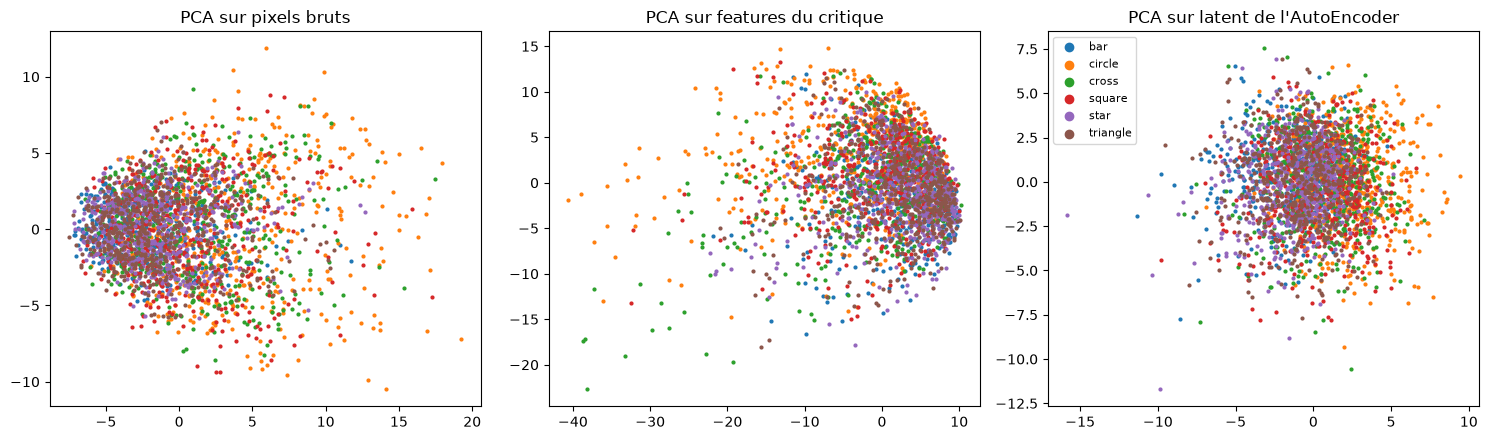

In [16]:
X_proj, y_proj = X[:N_PROJECTION], y[:N_PROJECTION]

# extract_features(X) -> (N, base*4*4*4) : derniere representation interne du critique
critic_features = gan.extract_features(X_proj)
print("features du critique:", critic_features.shape)

ae_codes = autoencoder.encode(X_proj).array
z_critic = PCA(n_components=2).fit(critic_features).encode(critic_features).array
z_pixels = PCA(n_components=2).fit(X_proj).encode(X_proj).array
z_ae = PCA(n_components=2).fit(ae_codes).encode(ae_codes).array

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, projection, title in [(axes[0], z_pixels, "PCA sur pixels bruts"),
                              (axes[1], z_critic, "PCA sur features du critique"),
                              (axes[2], z_ae, "PCA sur latent de l'AutoEncoder")]:
    for label, name in enumerate(class_names):
        mask = y_proj == label
        ax.scatter(projection[mask, 0], projection[mask, 1], s=4, label=name)
    ax.set_title(title)
axes[2].legend(markerscale=3, fontsize=8)
plt.tight_layout(); plt.show()

Les couleurs sont les vraies etiquettes, jamais vues par le GAN : elles ne servent qu'a juger la
projection a posteriori. Separabilite quantifiee par un kNN entraine sur les 2 composantes.

In [17]:
for name, projection in [("pixels bruts", z_pixels), ("features du critique", z_critic),
                         ("latent AutoEncoder", z_ae)]:
    accuracy = cross_val_score(KNeighborsClassifier(15), projection, y_proj, cv=3).mean()
    print(f"kNN sur 2 composantes ({name:<20}): {accuracy:.3f}")
print(f"{'hasard (6 formes equilibrees)':<43}: {1/6:.3f}")

kNN sur 2 composantes (pixels bruts        ): 0.245
kNN sur 2 composantes (features du critique): 0.242
kNN sur 2 composantes (latent AutoEncoder  ): 0.263
hasard (6 formes equilibrees)              : 0.167


### Lecture

Les features du critique (0.242) font **legerement moins bien que les pixels bruts** (0.245). Meme
conclusion que sur MNIST (0.430 contre 0.441), et pour la meme raison : le critique a ete entraine a
separer "reelle" de "fausse", pas a separer les formes. Rien dans sa loss ne l'encourage a
distinguer un carre d'une etoile, les deux etant de vraies images. Le detour est un echec mesure.

Le second enseignement est plus large : **les trois projections sont proches du hasard** (0.167).
En 2 composantes, la forme geometrique n'est pas separable, quelle que soit la representation. La
variance dominante de ce dataset est portee par la couleur, la taille et la position de l'objet,
pas par sa geometrie. Le latent de l'AutoEncoder (0.263) fait un peu mieux mais reste tres loin
d'une projection exploitable.

Recoupement avec les chiffres publies sur le meme lot dans `01_kmeans_shapes.ipynb` : un K-Means a
`k = 6` atteint 26.29% de precision forme, le meme ordre de grandeur. La difficulte vient donc du
dataset et non du seul GAN.

Verdict : non adapte, et le detour ne rattrape rien.

## Synthese

Mesures sur les 10000 images du pipeline partage, dimension latente 100 pour tous les modeles.

| Tache | Verdict | Mesure |
|---|---|---|
| Generation | Echec sur la geometrie | Couleurs, fond et parasites appris, aucune des 6 formes identifiable. Ecart de score du critique 3.79 (vraies -7.18, fausses -10.97), distance de Wasserstein en plateau a 3.87. Diversite intacte (ecart-type 0.173 contre 0.177), donc ce n'est pas un mode collapse |
| Compression | Utilisable, et meilleure que sur MNIST | MSE 0.00706 contre 0.00477 pour l'AE et 0.00766 pour la PCA. Ratio 14.81 contre 7.06 et 23.45. Rentable des 361 images. Cout : 300 pas de gradient par image a l'encodage |
| Projection | Non adapte | kNN 0.242 sur les features du critique contre 0.245 sur les pixels bruts, pour un hasard a 0.167 |

**Le resultat central est une inversion par rapport a MNIST.** Sur MNIST, le GAN reussissait la
generation et ratait les deux autres taches. Sur shapes, c'est l'inverse : la generation echoue sur
la geometrie, la compression devient competitive. Et les deux verdicts portent sur **le meme
generateur**, ce qui n'est pas une contradiction mais le fait le plus interessant du notebook : `G`
sait produire des formes nettes quand une descente de gradient va les chercher, et ne les produit
pas quand on tire `z` dans le prior. Les codes trouves par inversion sont pourtant statistiquement
dans le prior, ce qui elimine l'explication la plus simple.

Deux lecons de methode, payees par les mesures de ce notebook :

1. **Les metriques d'equilibre ne mesurent pas la qualite.** La config MNIST affiche ici les
   meilleures metriques de tout le notebook (accuracy de `D` a 0.549, quasi le 0.5 ideal) et produit
   les pires images. L'egalite peut etre obtenue par le bas, avec un `D` trop faible pour voir.
2. **Une correction n'est valable que contre la pathologie qu'elle vise.** Affaiblir `D` par du
   dropout a sauve MNIST ; ici cela detruit les detecteurs de bords. WGAN-GP n'a ete adopte qu'apres
   avoir mesure la saturation du BCE convolutif (accuracy 0.998, loss de `G` divergente), pas parce
   que le cours le mentionne.

Ce que le WGAN-GP a effectivement apporte : plus aucune pathologie d'entrainement, et une courbe
qui se lit. Ce qui reste n'est pas un probleme d'optimisation mais de couverture de la distribution.
Les pistes ouvertes se mesurent en budget (plus d'images, `G` plus large) ou changent le probleme
(GAN conditionne par la classe). Le passage a 32x32 ne justifie ni Progressive Growing ni MSG-GAN,
qui repondent a des difficultes de montee en resolution que ce dataset ne pose pas.